# Declaration of Originality

**School of Informatics & IT**
<br/>**Diploma in Applied Artificial Intelligence**
<br/>**Machine Learning for Developers (CAI2C08)**
<br/>**AY2026/2027 April Semester**
<br/>**Program Codes**

* Student Name:



**Declaration of Originality**
* I am the originator of this work, and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [ ]:

## Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Business Understanding

# Loan Approval Prediction

Goal: Predict whether or not a loan application will be approved or rejected 
based on the applicant's financial and demographic profile.

Why this matters and is important:
- Banks and financial institutions process thousands of loan applications 
  every day. Manual review is very time consuming, inconsistent and also prone to 
  human bias.
- A machine learning model that predicts loan approval based on financial 
  data can help banks make faster, fairer and more consistent lending 
  decisions.
- This reduces the risk of bad loans while ensuring creditworthy applicants 
  are not unfairly rejected.

Type of problem: Binary Classification
- Target variable: loan_status (Approved = 1, Rejected = 0)

Dataset: Loan Approval Prediction Dataset, sourced from Kaggle.com
- 4,269 rows, 13 columns
- Features include applicant demographics, income, loan details, 
  and asset values

# 2. Data Understanding

## 2.1 Load dataset

In [ ]:
## Read *.csv file into pandas DataFrame
## Read *.csv file into pandas DataFrame
FILE_PATH = "loan_approval_dataset.csv"
df = pd.read_csv(FILE_PATH)

## Strip leading/trailing spaces from column names
df.columns = df.columns.str.strip()

df

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


## 2.2 Summary Statistics

In [ ]:
## Understand the type of variable for each column
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   loan_id                   4269 non-null   int64
 1   no_of_dependents          4269 non-null   int64
 2   education                 4269 non-null   str  
 3   self_employed             4269 non-null   str  
 4   income_annum              4269 non-null   int64
 5   loan_amount               4269 non-null   int64
 6   loan_term                 4269 non-null   int64
 7   cibil_score               4269 non-null   int64
 8   residential_assets_value  4269 non-null   int64
 9   commercial_assets_value   4269 non-null   int64
 10  luxury_assets_value       4269 non-null   int64
 11  bank_asset_value          4269 non-null   int64
 12  loan_status               4269 non-null   str  
dtypes: int64(10), str(3)
memory usage: 531.6 KB


In [ ]:
## Check for missing data
df.isna().sum()

loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

In [ ]:
## Describe data distribution
df.describe(include="all")

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
count,4269.000000,4269.000000,4269,4269,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03,4269
unique,NaN,NaN,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,Graduate,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Approved
freq,NaN,NaN,2144,2150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2656
mean,2135.000000,2.498712,NaN,NaN,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06,NaN
std,1232.498479,1.695910,NaN,NaN,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06,NaN
min,1.000000,0.000000,NaN,NaN,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00,NaN
25%,1068.000000,1.000000,NaN,NaN,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06,NaN
50%,2135.000000,3.000000,NaN,NaN,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06,NaN
75%,3202.000000,4.000000,NaN,NaN,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06,NaN


No missing values found (isna().sum() all 0). Data types look correct thus no conversion needed. describe() confirms feature ranges look sensible (e.g. cibil_score 300–900, no negative values in most columns except residential_assets_value flagged in cleaning below)


## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

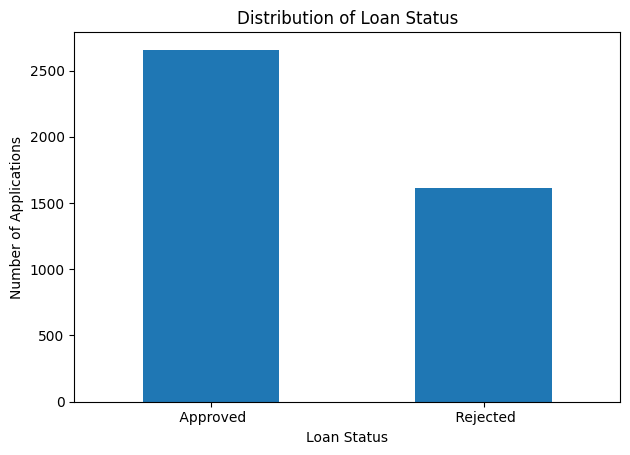

In [ ]:
## Understanding distribution of target
col_y = "loan_status"

df[col_y].value_counts().plot(kind='bar')
plt.title("Distribution of Loan Status")
plt.suptitle('')
plt.xlabel("Loan Status")
plt.ylabel("Number of Applications")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Observations:
- The dataset is slightly imbalanced : 2,656 applications were Approved (62%) 
  and 1,613 were Rejected (38%)
- While not severely imbalanced, we will use the classification report 
  alongside accuracy for a more complete evaluation.

### 2.3.1.2 Understanding distribution of features

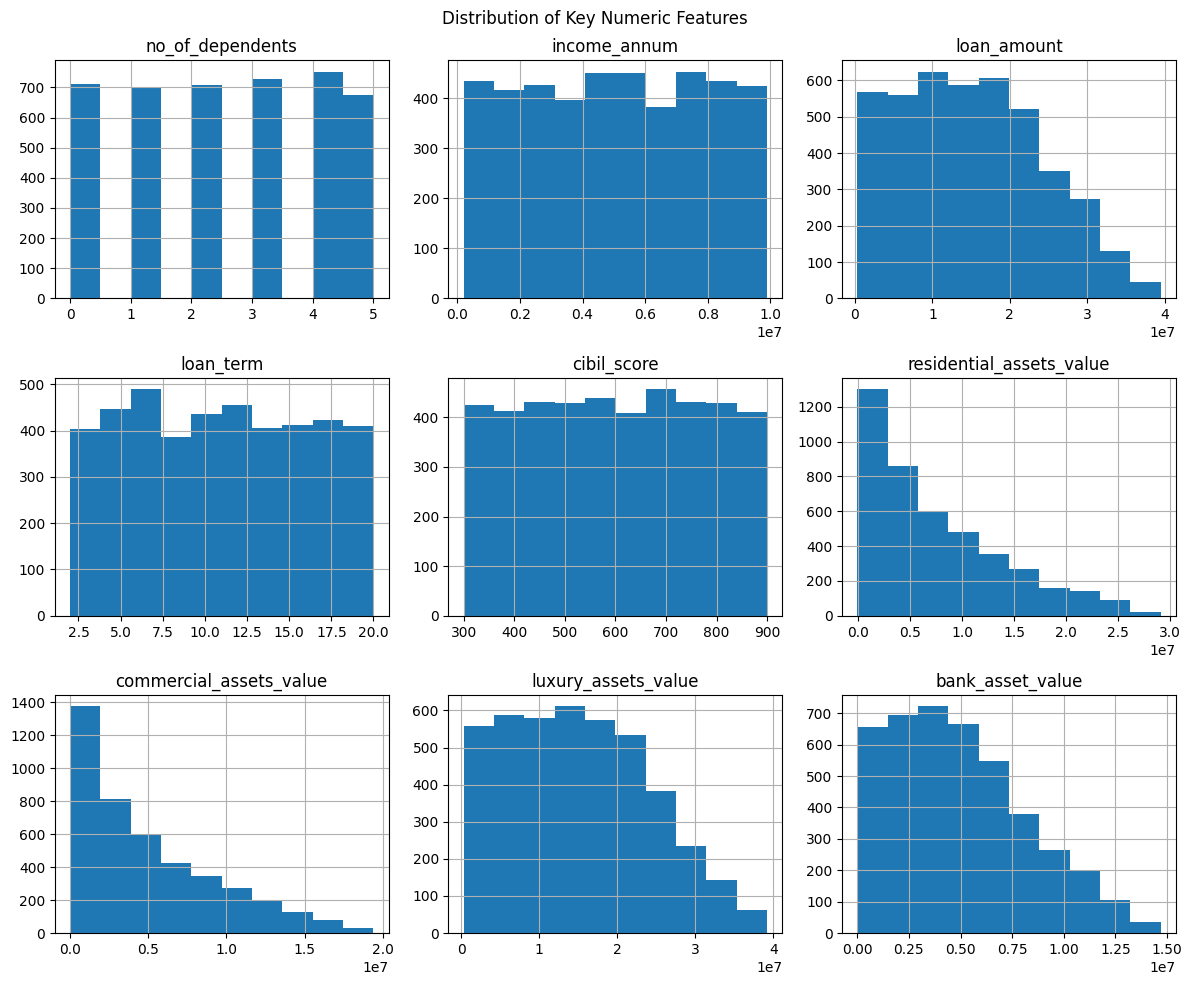

In [ ]:
## Understanding distribution of features
## Plot histogram of key numeric features
key_features = ['no_of_dependents', 'income_annum', 'loan_amount', 
                'loan_term', 'cibil_score', 'residential_assets_value',
                'commercial_assets_value', 'luxury_assets_value', 
                'bank_asset_value']

df[key_features].hist(layout=(3, 3), figsize=(12, 10))
plt.suptitle("Distribution of Key Numeric Features")
plt.tight_layout()
plt.show()

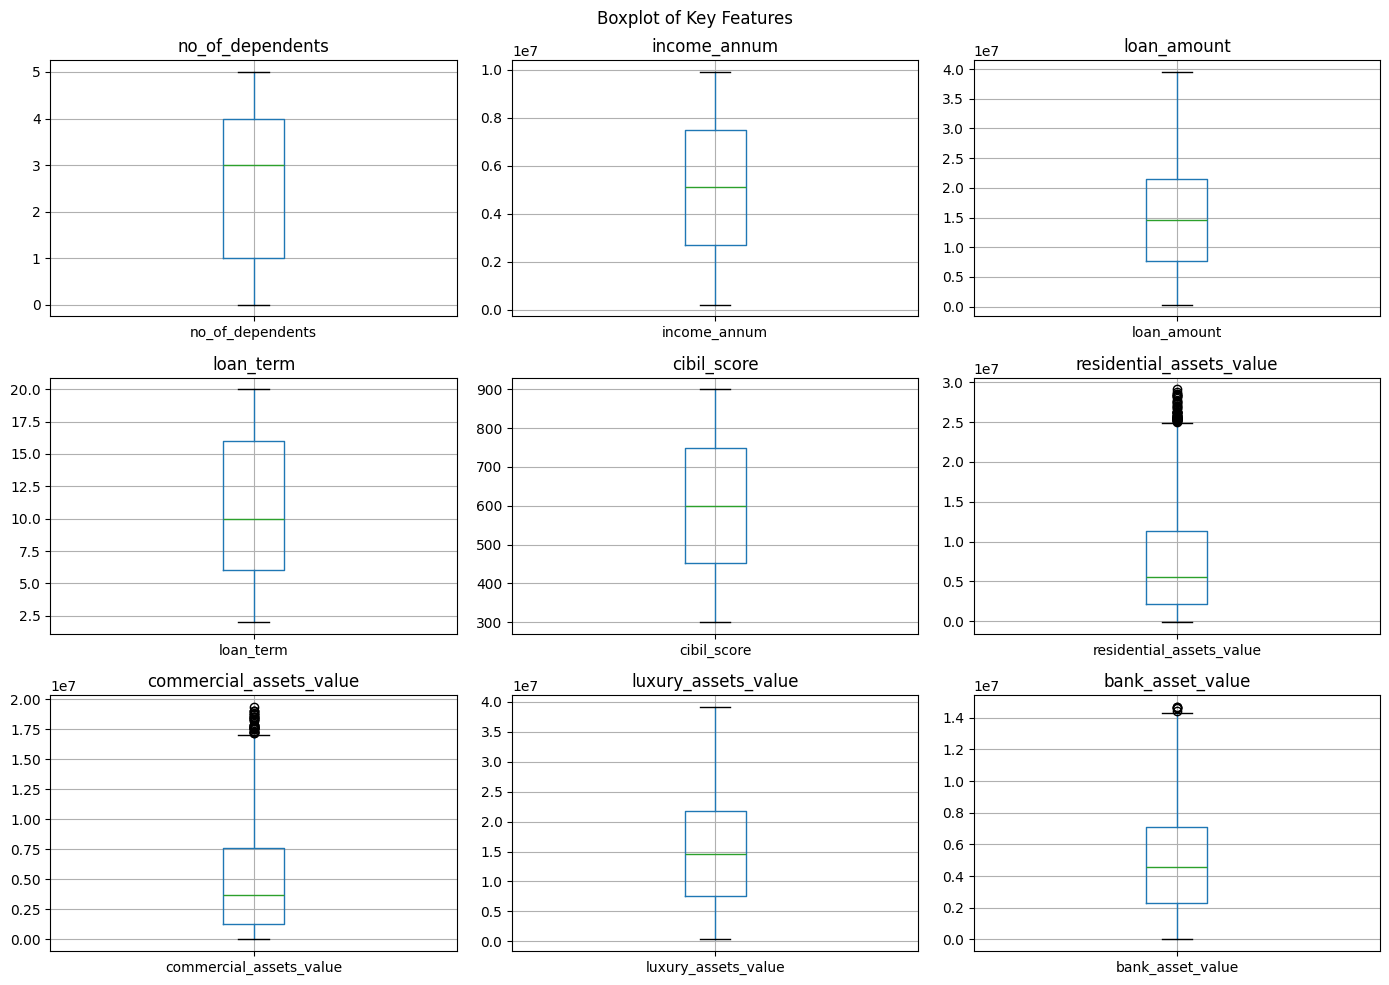

In [ ]:
## Plot boxplot of key features separately
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(key_features):
    df.boxplot(column=col, ax=axes[i])
    axes[i].set_title(col)

plt.suptitle("Boxplot of Key Features")
plt.tight_layout()
plt.show()

Observations:
- no_of_dependents — evenly spread with no outliers, median is around 3
- income_annum — fairly uniform spread, no significant outliers
- loan_amount — wide spread with a few high value outliers, 
  most loans are in the lower range
- loan_term — median around 10 years, spread evenly across all terms
- cibil_score — wide spread from 300-900 with no outliers, 
  confirming uniform distribution across all credit scores
- residential_assets_value — several high value outliers, 
  most applicants have lower value residential assets
- commercial_assets_value — extreme outliers at very high values, 
  most applicants have low commercial assets
- luxury_assets_value — wide spread with some high value outliers
- bank_asset_value — a few extreme outliers at very high values

### 2.3.2 Understanding relationship between variables

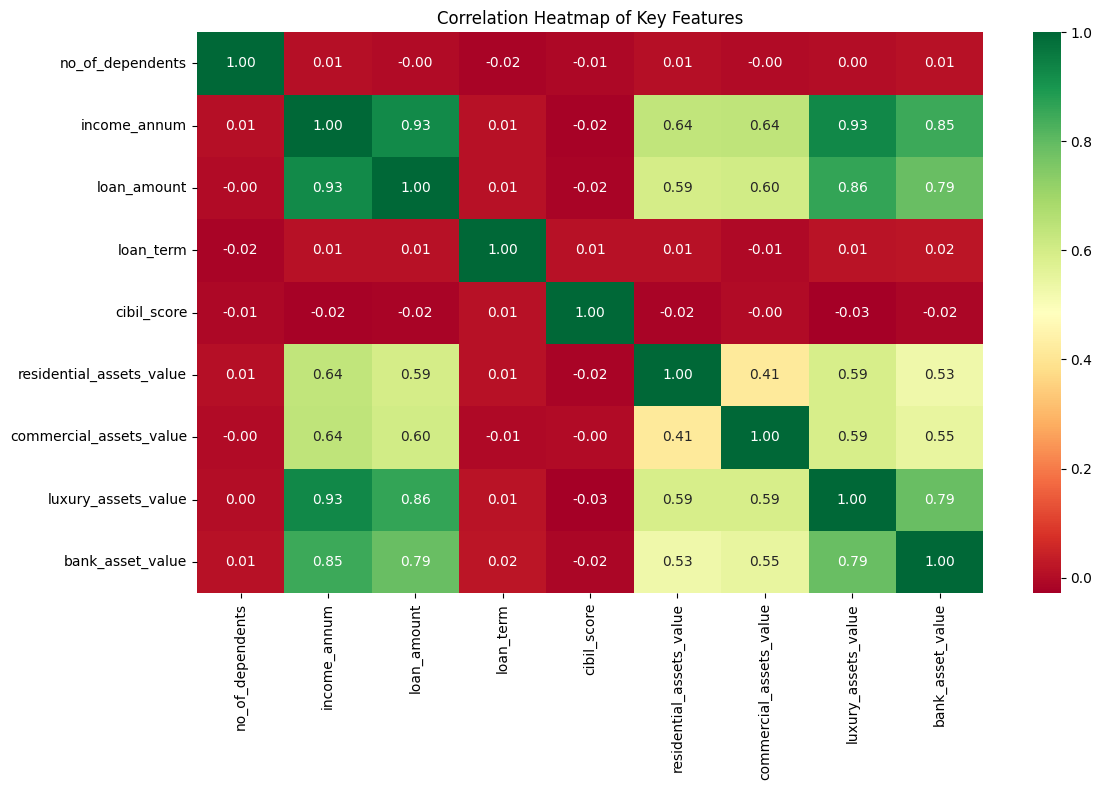

In [ ]:
## Understanding relationship between variables
## Plot correlation heatmap of numeric features only
df_corr = df[key_features].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(df_corr, annot=True, fmt=".2f", cmap='RdYlGn')
plt.title("Correlation Heatmap of Key Features")
plt.tight_layout()
plt.show()

Observations:
- income_annum and loan_amount are highly correlated (0.93), meaning 
  applicants with higher income tend to request larger loans
- income_annum and luxury_assets_value are highly correlated (0.93), 
  suggesting higher earners tend to own more luxury assets
- income_annum and bank_asset_value are strongly correlated (0.85), 
  higher income applicants tend to have more bank assets
- loan_amount and luxury_assets_value are strongly correlated (0.86), 
  larger loan requests tend to come from applicants with more luxury assets
- cibil_score has very low correlation with all other features (close to 0), 
  meaning it is an independent predictor and this is expected as credit score 
  is calculated separately from income and assets
- no_of_dependents and loan_term show very low correlation with all 
  other features

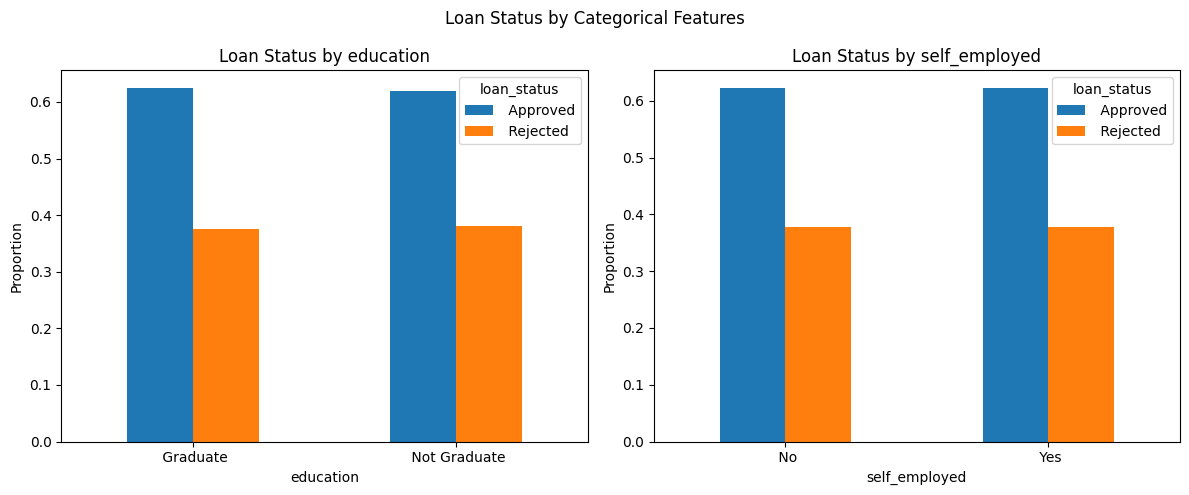

In [ ]:
## Plot loan status by categorical features
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, col in enumerate(['education', 'self_employed']):
    df.groupby(col)[col_y].value_counts(normalize=True).unstack().plot(
        kind='bar', ax=axes[i])
    axes[i].set_title(f'Loan Status by {col}')
    axes[i].set_ylabel('Proportion')
    axes[i].set_xlabel(col)
    axes[i].tick_params(axis='x', rotation=0)

plt.suptitle("Loan Status by Categorical Features")
plt.tight_layout()
plt.show()

Observations:
- Education: both Graduate and Not Graduate applicants have similar 
  approval rates (around 62%), suggesting education level alone does not 
  significantly impact loan approval
- Self Employed: both self employed and non self employed applicants 
  have similar approval rates (around 62%), suggesting employment type alone 
  does not significantly impact loan approval
- Both categorical features show similar distributions, indicating that 
  the numeric features like cibil_score and income_annum are likely 
  stronger predictors of loan approval

# 3. Data Preparation

## 3.1 Data Cleaning

### 3.1 Dropping Irrelevant Columns

The following columns are dropped as they have no predictive value:
- loan_id — just a unique identifier, not a feature

In [ ]:
## Clean data
## Drop irrelevant columns
df = df.drop(['loan_id'], axis=1)

## Confirm
print("Shape after dropping irrelevant columns:", df.shape)
df.head()

Shape after dropping irrelevant columns: (4269, 12)


,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


###  Data Cleaning

During data understanding, we noticed residential_assets_value has a 
minimum value of -100,000 which is not possible for an asset value. 
We will remove this row as it is likely a data entry error.

In [ ]:
## Remove rows with negative residential_assets_value
df = df[df['residential_assets_value'] >= 0]

## Confirm
print("Shape after cleaning:", df.shape)

Shape after cleaning: (4241, 12)


###  Feature Engineering — One-Hot Encoding

education and self_employed are categorical columns. We apply 
One-Hot Encoding to convert them into numeric format so they 
can be used by machine learning models.

In [ ]:
## Strip spaces from loan_status values and encode
## Approved = 1, Rejected = 0
df['loan_status'] = df['loan_status'].str.strip()
df['loan_status'] = df['loan_status'].map({'Approved': 1, 'Rejected': 0})

## Confirm
print(df['loan_status'].value_counts())

loan_status
1    2640
0    1601
Name: count, dtype: int64


In [ ]:
## Apply One-Hot Encoding to categorical columns
df = pd.get_dummies(df, columns=['education', 'self_employed'], 
                    drop_first=True)

## Confirm
print("Shape after One-Hot Encoding:", df.shape)
df.head()

Shape after One-Hot Encoding: (4241, 12)


,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,education_ Not Graduate,self_employed_ Yes
0,2,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1,False,False
1,0,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0,True,True
2,3,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0,False,False
3,3,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0,False,False
4,5,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0,True,True


## 3.2 Train-Test Split

In [ ]:
## Split data into train set and test set
from sklearn.model_selection import train_test_split

## Split data into features (X) and target (y)
col_y = 'loan_status'
y = df[col_y]
X = df.drop(col_y, axis=1)

## Split into train and test sets (70% train, 30% test)
test_size = 0.3
random_state = 2026

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                      test_size=test_size,
                                                      random_state=random_state)


# 4. Modelling

We will train and compare 3 classification models:
1. Logistic Regression — simple linear baseline model
2. Random Forest Classifier — ensemble model using bagging
3. Gradient Boosting Classifier — ensemble model using boosting


### 4.2 Train Model

In [ ]:
## Initialise and train model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

## Initialise and train model
lr = LogisticRegression(random_state=2026, max_iter=1000)
lr.fit(X_train, y_train)

## Evaluate model
y_pred_lr = lr.predict(X_test)
print("Logistic Regression: ", accuracy_score(y_test, y_pred_lr))

## Save model
import joblib
joblib.dump(lr, 'lr_model.pkl')

Logistic Regression:  0.788688138256088


['lr_model.pkl']

In [ ]:
from sklearn.ensemble import RandomForestClassifier

## Initialise and train model
rf = RandomForestClassifier(random_state=2026)
rf.fit(X_train, y_train)

## Evaluate model
y_pred_rf = rf.predict(X_test)
print("Random Forest Classifier: ", accuracy_score(y_test, y_pred_rf))

## Save model
import joblib
joblib.dump(rf, 'rf_model.pkl')

Random Forest Classifier:  0.9748625294579732


['rf_model.pkl']

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

## Initialise and train model
gb = GradientBoostingClassifier(random_state=2026)
gb.fit(X_train, y_train)

## Evaluate model
y_pred_gb = gb.predict(X_test)
print("Gradient Boosting Classifier: ", accuracy_score(y_test, y_pred_gb))

## Save model
import joblib
joblib.dump(gb, 'gb_model.pkl')

Gradient Boosting Classifier:  0.9780047132757266


['gb_model.pkl']

In [ ]:
## Compare all models
print(f"{'Model':<30} {'Test Acc':>8}")
print(f"{'Logistic Regression':<30} {accuracy_score(y_test, y_pred_lr):>8.4f}")
print(f"{'Random Forest':<30} {accuracy_score(y_test, y_pred_rf):>8.4f}")
print(f"{'Gradient Boosting':<30} {accuracy_score(y_test, y_pred_gb):>8.4f}")

Model                          Test Acc
Logistic Regression              0.7887
Random Forest                    0.9749
Gradient Boosting                0.9780


### Model Selection

Selected Model: Gradient Boosting Classifier
- Achieves the highest test accuracy of 97.80%
- Gradient Boosting handles the mix of numeric and encoded categorical 
  features in this dataset better than a linear model
- We will tune this model further using RandomizedSearchCV

### Hyperparameter Tuning — Gradient Boosting Classifier

We use RandomizedSearchCV to find the best hyperparameters for our 
selected Gradient Boosting Classifier. We tune 2 hyperparameters 
with 3 values each:
- n_estimators — number of boosting stages (trees)
- learning_rate — controls how much each tree contributes

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

## Define hyperparameter grid (max 3 values each)
param_dist = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.2]
}

## RandomizedSearchCV with 5-fold cross validation
random_search = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=2026),
    param_distributions=param_dist,
    n_iter=9,
    cv=5,
    scoring='accuracy',
    random_state=2026,
    verbose=1
)

random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best CV Accuracy:", f"{random_search.best_score_:.4f}")

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best Parameters: {'n_estimators': 100, 'learning_rate': 0.2}
Best CV Accuracy: 0.9821


In [ ]:
## Get best model from RandomizedSearchCV
best_model = random_search.best_estimator_

## Evaluate tuned model
y_pred_best = best_model.predict(X_test)
print("Tuned Gradient Boosting Classifier: ", accuracy_score(y_test, y_pred_best))
print()
print("Comparison:")
print("Before tuning:", f"{accuracy_score(y_test, y_pred_gb):.4f}")
print("After tuning: ", f"{accuracy_score(y_test, y_pred_best):.4f}")

## Save best tuned model
import joblib
joblib.dump(best_model, 'best_model.pkl')
print("\nBest model saved as best_model.pkl")

Tuned Gradient Boosting Classifier:  0.98114689709348

Comparison:
Before tuning: 0.9780
After tuning:  0.9811

Best model saved as best_model.pkl


Observations:
- Best parameters found: n_estimators=100, learning_rate=0.2
- Test accuracy improved after tuning: 97.80% to 98.11%
- The tuned Gradient Boosting model is selected as our final model 
  as it achieves the best test accuracy through a rigorous 
  cross-validated search process with a CV accuracy of 98.21%

# 5. Model Evaluation

In [ ]:
## Evaluate model
from sklearn.metrics import confusion_matrix

## Confusion matrix
confusion_matrix(y_test, y_pred_best)

array([[460,  17],
       [  7, 789]])

Confusion Matrix Results:
- True Negatives (TN): 460 — correctly predicted Rejected
- False Positives (FP): 17 — incorrectly predicted Approved when actually Rejected
- False Negatives (FN): 7 — incorrectly predicted Rejected when actually Approved
- True Positives (TP): 789 — correctly predicted Approved

The model has very few misclassifications — only 24 out of 1,273 
test samples were incorrectly predicted.

In [ ]:
from sklearn.metrics import classification_report

## Classification report
print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.99      0.96      0.97       477
           1       0.98      0.99      0.99       796

    accuracy                           0.98      1273
   macro avg       0.98      0.98      0.98      1273
weighted avg       0.98      0.98      0.98      1273



In [ ]:
## New data — sample loan application
col_df_X = df.drop('loan_status', axis=1).columns
col_ohe = X.columns.tolist()

X_unseen = [['Graduate', 'No', 2, 5000000, 12000000, 10, 750, 
             5000000, 3000000, 8000000, 4000000]]

## Convert to pandas dataframe
X_unseen = pd.DataFrame(X_unseen, columns=col_df_X)

## Apply OHE
X_unseen = pd.get_dummies(X_unseen, drop_first=True)

## Reindex to match training columns
X_unseen = X_unseen.reindex(columns=col_ohe, fill_value=0)

display(X_unseen)

## Predict
prediction = best_model.predict(X_unseen)
print("Prediction:", "Approved" if prediction[0] == 1 else "Rejected")

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,education_ Not Graduate,self_employed_ Yes
0,0,0,2,5000000,12000000,10,750,5000000,3000000,8000000,4000000


Prediction: Approved


Predicting on a new unseen loan application:
- Applicant is a Graduate, not self employed
- Annual income: 5,000,000
- Loan amount requested: 12,000,000
- Loan term: 10 years
- CIBIL score: 750 (good credit score)
- Total assets: residential 5M, commercial 3M, luxury 8M, bank 4M

Prediction: Approved
- The model correctly identifies this as a strong application 
  due to the high CIBIL score, stable income and sufficient assets 
  to cover the loan amount

## Iterative model development


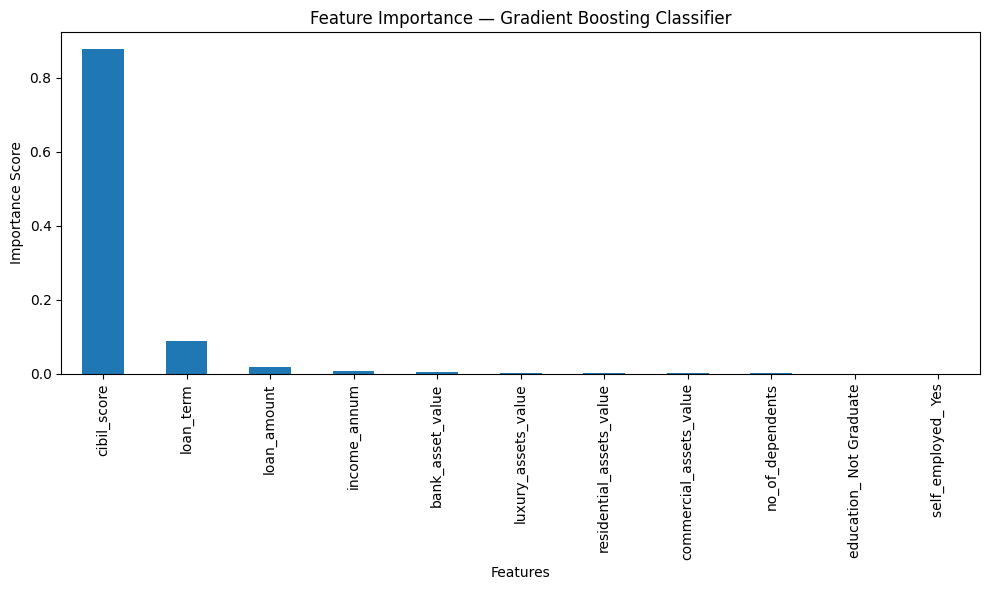

cibil_score                 0.878191
loan_term                   0.087832
loan_amount                 0.018449
income_annum                0.006352
bank_asset_value            0.003907
luxury_assets_value         0.002667
residential_assets_value    0.001324
commercial_assets_value     0.000590
no_of_dependents            0.000374
education_ Not Graduate     0.000203
self_employed_ Yes          0.000110
dtype: float64


In [ ]:
## Further feature engineering / feature selection
## Plot feature importance of best model
feature_importance = pd.Series(best_model.feature_importances_, 
                                index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feature_importance.plot(kind='bar')
plt.title("Feature Importance — Gradient Boosting Classifier")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

print(feature_importance)

Observations:
- cibil_score is overwhelmingly the most important feature (0.85), 
  confirming that credit score is the primary factor in loan approval decisions
- loan_term and loan_amount are the next most important features
- income_annum and bank_asset_value have small but notable importance
- education and self_employed have near zero importance, confirming 
  our earlier observation that these features have minimal impact on 
  loan approval

Based on this analysis, we attempt to retrain the model using only 
the top features to see if we can simplify the model without 
losing accuracy.

In [ ]:
## Retrain model using only top features
top_features = ['cibil_score', 'loan_term', 'loan_amount', 
                'income_annum', 'bank_asset_value']

X_train_top = X_train[top_features]
X_test_top = X_test[top_features]

## Train model with top features only
gb_top = GradientBoostingClassifier(n_estimators=100, 
                                     learning_rate=0.2,
                                     random_state=2026)
gb_top.fit(X_train_top, y_train)

y_pred_top = gb_top.predict(X_test_top)
print("Tuned GB with top features: ", accuracy_score(y_test, y_pred_top))
print("Tuned GB with all features: ", accuracy_score(y_test, y_pred_best))

Tuned GB with top features:  0.983503534956795
Tuned GB with all features:  0.98114689709348


Observations:
- The model trained on only the top 5 features achieved 98.35% accuracy, 
  slightly higher than the full model with all features (98.11%)
- This confirms that the low importance features (education, self_employed, 
  residential_assets_value, commercial_assets_value, luxury_assets_value, 
  no_of_dependents) were adding noise rather than useful information
- A simpler model with fewer features is preferred as it is easier to 
  interpret, faster to train, and generalises better to new data
- We will use this simplified model as our final model for deployment


In [ ]:
## Update final model to simplified version
best_model = gb_top

## Save updated final model
import joblib
joblib.dump(best_model, 'best_model.pkl')
print("Updated best model saved!")

Updated best model saved!
